In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/carlolepelaars/camvid/CamVid/class_dict.csv
/kaggle/input/datasets/carlolepelaars/camvid/CamVid/val_labels/0016E5_08045_L.png
/kaggle/input/datasets/carlolepelaars/camvid/CamVid/val_labels/0016E5_04740_L.png
/kaggle/input/datasets/carlolepelaars/camvid/CamVid/val_labels/Seq05VD_f03180_L.png
/kaggle/input/datasets/carlolepelaars/camvid/CamVid/val_labels/0016E5_08107_L.png
/kaggle/input/datasets/carlolepelaars/camvid/CamVid/val_labels/0016E5_06900_L.png
/kaggle/input/datasets/carlolepelaars/camvid/CamVid/val_labels/0016E5_02010_L.png
/kaggle/input/datasets/carlolepelaars/camvid/CamVid/val_labels/0006R0_f02550_L.png
/kaggle/input/datasets/carlolepelaars/camvid/CamVid/val_labels/0016E5_08610_L.png
/kaggle/input/datasets/carlolepelaars/camvid/CamVid/val_labels/0001TP_009300_L.png
/kaggle/input/datasets/carlolepelaars/camvid/CamVid/val_labels/0016E5_08047_L.png
/kaggle/input/datasets/carlolepelaars/camvid/CamVid/val_labels/0016E5_01980_L.png
/kaggle/input/datasets/carl

In [2]:
import numpy as np
import os
import pandas as pd
import re
from PIL import Image
import torchvision
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation import deeplabv3_resnet101
from sklearn.model_selection import train_test_split

2026-06-26 11:28:34.398592: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782473314.635550      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782473314.701820      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782473315.261525      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782473315.261562      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782473315.261565      23 computation_placer.cc:177] computation placer alr

In [3]:
framObjTrain = {'img' : [],
           'mask' : []
          }

framObjValidation = {'img' : [],
           'mask' : []
          }

framObjTest = {'img' : [],
           'mask' : []
          }

In [4]:
train_path = '/kaggle/input/datasets/carlolepelaars/camvid/CamVid/train'
test_path = '/kaggle/input/datasets/carlolepelaars/camvid/CamVid/test'
val_path = '/kaggle/input/datasets/carlolepelaars/camvid/CamVid/val'

In [5]:
df = pd.read_csv('/kaggle/input/datasets/carlolepelaars/camvid/CamVid/class_dict.csv')
df.head()

,name,r,g,b
0,Animal,64,128,64
1,Archway,192,0,128
2,Bicyclist,0,128,192
3,Bridge,0,128,64
4,Building,128,0,0


In [6]:
df.info()
k = df.shape
k

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    32 non-null     object
 1   r       32 non-null     int64 
 2   g       32 non-null     int64 
 3   b       32 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.1+ KB


(32, 4)

In [7]:
df.head()

,name,r,g,b
0,Animal,64,128,64
1,Archway,192,0,128
2,Bicyclist,0,128,192
3,Bridge,0,128,64
4,Building,128,0,0


In [8]:
df.head()
colors = df.iloc[:, 1:4]
colors.head()
mask_map = colors.to_numpy()

In [9]:
mask_category = df['name'].tolist()
mask_category

['Animal',
 'Archway',
 'Bicyclist',
 'Bridge',
 'Building',
 'Car',
 'CartLuggagePram',
 'Child',
 'Column_Pole',
 'Fence',
 'LaneMkgsDriv',
 'LaneMkgsNonDriv',
 'Misc_Text',
 'MotorcycleScooter',
 'OtherMoving',
 'ParkingBlock',
 'Pedestrian',
 'Road',
 'RoadShoulder',
 'Sidewalk',
 'SignSymbol',
 'Sky',
 'SUVPickupTruck',
 'TrafficCone',
 'TrafficLight',
 'Train',
 'Tree',
 'Truck_Bus',
 'Tunnel',
 'VegetationMisc',
 'Void',
 'Wall']

In [10]:
def LoadData( frameObj = None, imgPath = None, maskPath = None, shape = 256):
    imgNames = os.listdir(imgPath)
    maskNames = []

    for mem in imgNames:
        maskNames.append(re.sub('\.png', '_L.png', mem))

    imgAddr = imgPath + '/'
    maskAddr = maskPath + '/'

    for i in range (len(imgNames)):
        img = plt.imread(imgAddr + imgNames[i])
        mask = plt.imread(maskAddr + maskNames[i])
    
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (shape, shape))
        mask = cv2.resize(mask, (shape, shape))
    
        frameObj['img'].append(img)
        frameObj['mask'].append(mask)

    return frameObj
    

<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_23/1405200646.py:6: SyntaxWarning: invalid escape sequence '\.'
  maskNames.append(re.sub('\.png', '_L.png', mem))


In [11]:
'''
1. Resize
2. color space
3. rgb to label -> using function
4. normalize -> using transform
5. augmentation
6. convert to tensor -> using transform

'''

'\n1. Resize\n2. color space\n3. rgb to label -> using function\n4. normalize -> using transform\n5. augmentation\n6. convert to tensor -> using transform\n\n'

In [12]:
class ImageDataset(Dataset):
    def __init__(self, root, transform=None):

        self.image_dir = root
        self.mask_dir = root + "_labels"      # store the DIRECTORY path

        self.images = sorted(os.listdir(self.image_dir))
        self.masks = sorted(os.listdir(self.mask_dir))
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self):
        return len(self.images)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index):

        image_path = os.path.join(self.image_dir, self.images[index])
        mask_path = os.path.join(self.mask_dir, self.masks[index])
    
        # Read image
        image = Image.open(image_path).resize((256, 256)).convert("RGB")
    
        # Read mask
        mask_rgb = np.array(
            Image.open(mask_path)
            .resize((256, 256), Image.Resampling.NEAREST)
            .convert("RGB")
        )
    
        # Convert RGB mask -> class index mask (H, W)
        label_map = to_label(mask_rgb)
    
        # Apply transform ONLY to image
        if self.transform:
            image = self.transform(image)
    
        # Convert label map directly to tensor
        mask = torch.from_numpy(label_map).long()
    
        return image, mask

In [13]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True), 
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    
])

In [14]:
def to_label(mask_rgb):
    h, w = mask_rgb.shape[:2]
    label = np.zeros((h, w), dtype=np.int64)
    for idx, color in enumerate(mask_map):
        label[np.all(mask_rgb == color, axis=-1)] = idx
    return label

In [15]:
train_dl = ImageDataset(train_path, transform=transform)
test_dl = ImageDataset(test_path, transform=transform)
val_dl = ImageDataset(val_path, transform=transform)

In [16]:
trainLoader = DataLoader(train_dl, batch_size=8, shuffle=True, drop_last=True)
testLoader = DataLoader(test_dl, batch_size=8, shuffle=True)
valLoader = DataLoader(val_dl, batch_size=8, shuffle=False)

In [17]:
type(trainLoader)
#train_dl.

torch.utils.data.dataloader.DataLoader

In [18]:
img, mask = train_dl[0]
img.shape
mask.shape

torch.Size([256, 256])

In [19]:
print(os.listdir(train_path)[:10])

['0001TP_009780.png', '0016E5_07963.png', 'Seq05VD_f01950.png', 'Seq05VD_f01590.png', '0016E5_02070.png', '0016E5_08035.png', '0006R0_f01710.png', 'Seq05VD_f01020.png', '0016E5_07999.png', 'Seq05VD_f00090.png']


In [20]:
print((os.listdir(train_path +"_labels"))[:10])

['0016E5_01440_L.png', '0006R0_f02010_L.png', '0006R0_f03360_L.png', '0016E5_04950_L.png', '0016E5_07290_L.png', '0016E5_04920_L.png', '0006R0_f01440_L.png', 'Seq05VD_f02490_L.png', '0016E5_05280_L.png', '0016E5_08117_L.png']


In [21]:
type(os.listdir(train_path))

list

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torch.hub.load('pytorch/vision:v0.10.0', 'deeplabv3_resnet50', pretrained=True)
model.classifier[4] = nn.Conv2d(256, 32, kernel_size=1)
model = model.to(device)
model.eval()

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 195MB/s]


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [24]:
epochs = 30
num_classes = len(mask_category)

In [25]:
def train(trainLoader, valLoader, epochs):
    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)['out']
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)['out']
                loss = criterion(outputs, masks)
                val_loss += loss.item()

In [26]:
import matplotlib.pyplot as plt

def train(model, trainLoader, valLoader, epochs, num_classes):

    train_losses = []
    val_losses = []
    val_mious = []

    for epoch in range(epochs):

        model.train()

        running_train_loss = 0

        for images, masks in trainLoader:

            images = images.to(device)
            masks = masks.to(device).long()

            optimizer.zero_grad()

            outputs = model(images)['out']

            loss = criterion(outputs, masks)

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        epoch_train_loss = running_train_loss / len(trainLoader)

        model.eval()

        running_val_loss = 0
        running_miou = 0

        with torch.no_grad():

            for images, masks in valLoader:

                images = images.to(device)
                masks = masks.to(device).long()

                outputs = model(images)['out']

                loss = criterion(outputs, masks)

                running_val_loss += loss.item()

                running_miou += compute_miou(outputs,
                                             masks,
                                             num_classes)

        epoch_val_loss = running_val_loss / len(valLoader)
        epoch_miou = running_miou / len(valLoader)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        val_mious.append(epoch_miou)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val mIoU: {epoch_miou:.4f}"
        )

    return train_losses, val_losses, val_mious

In [27]:
def compute_miou(preds, masks, num_classes):
    preds = torch.argmax(preds, dim=1)

    ious = []

    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (masks == cls)

        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()

        if union == 0:
            continue

        ious.append(intersection / union)

    if len(ious) == 0:
        return 0.0

    return torch.mean(torch.stack(ious)).item()

In [28]:
train_losses, val_losses, val_mious = train(model, trainLoader, valLoader, epochs, num_classes)

Epoch [1/30] | Train Loss: 2.1406 | Val Loss: 1.3464 | Val mIoU: 0.1839
Epoch [2/30] | Train Loss: 1.2531 | Val Loss: 1.0973 | Val mIoU: 0.2015
Epoch [3/30] | Train Loss: 1.0016 | Val Loss: 0.9483 | Val mIoU: 0.2141
Epoch [4/30] | Train Loss: 0.8473 | Val Loss: 0.8154 | Val mIoU: 0.2259
Epoch [5/30] | Train Loss: 0.7347 | Val Loss: 0.7554 | Val mIoU: 0.2386
Epoch [6/30] | Train Loss: 0.6481 | Val Loss: 0.6827 | Val mIoU: 0.2504
Epoch [7/30] | Train Loss: 0.5765 | Val Loss: 0.6235 | Val mIoU: 0.2673
Epoch [8/30] | Train Loss: 0.5175 | Val Loss: 0.5885 | Val mIoU: 0.2755
Epoch [9/30] | Train Loss: 0.4744 | Val Loss: 0.5549 | Val mIoU: 0.2950
Epoch [10/30] | Train Loss: 0.4356 | Val Loss: 0.5330 | Val mIoU: 0.3061
Epoch [11/30] | Train Loss: 0.4018 | Val Loss: 0.5060 | Val mIoU: 0.3254
Epoch [12/30] | Train Loss: 0.3745 | Val Loss: 0.4870 | Val mIoU: 0.3314
Epoch [13/30] | Train Loss: 0.3484 | Val Loss: 0.4697 | Val mIoU: 0.3409
Epoch [14/30] | Train Loss: 0.3289 | Val Loss: 0.4615 | Val 

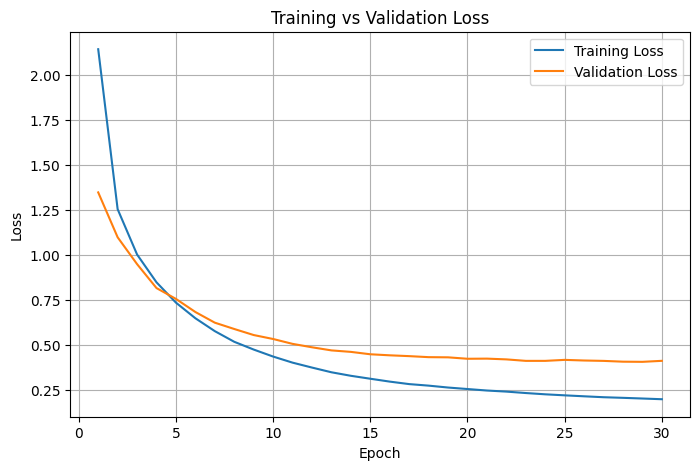

In [29]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("train-vs-val-loss.png", bbox_inches="tight", dpi=150)
plt.show()

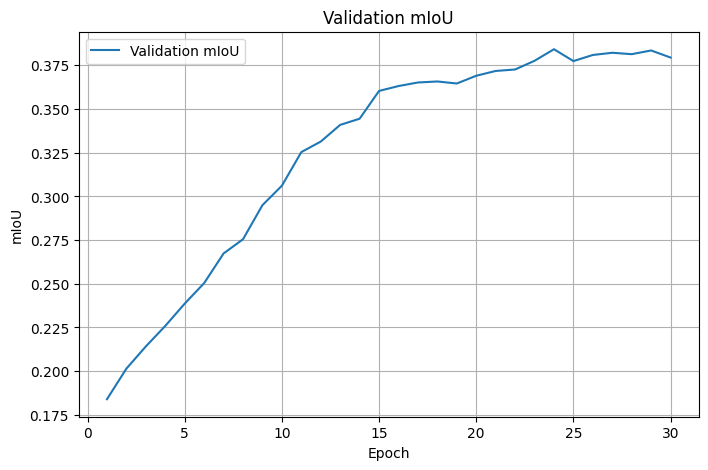

In [30]:
plt.figure(figsize=(8,5))
plt.plot(epochs, val_mious, label='Validation mIoU')
plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.title("Validation mIoU")
plt.legend()
plt.grid(True)
plt.savefig("val-mIoU.png", bbox_inches="tight", dpi=150)
plt.show()

In [31]:
def test_deeplabv3(model, testLoader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    
    predictions = []
    ground_truths = []
    images_list = []

    with torch.no_grad():
        for images, masks in testLoader:
            images = images.to(device)
            outputs = model(images)['out']
            preds = outputs.argmax(dim=1)

            predictions.extend(preds.cpu().numpy())
            ground_truths.extend(masks.numpy())
            images_list.extend(images.cpu().numpy())

    return predictions, ground_truths, images_list


In [32]:
def label_to_rgb(label: np.ndarray) -> np.ndarray:
    """Integer label map (H, W) → RGB image (H, W, 3)."""
    rgb = np.zeros((*label.shape, 3), dtype=np.uint8)
    for idx, color in enumerate(mask_map):
        rgb[label == idx] = color
    return rgb


In [33]:
def denormalize(img):
    if isinstance(img, torch.Tensor):
        img = img.cpu().numpy()

    mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
    std  = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)

    img = img * std + mean
    img = np.clip(img, 0, 1)
    img = img.transpose(1,2,0)

    return img

In [34]:
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [35]:
def plot_prediction_grid(image_list, gt_list, pred_list, num_samples=4, save_path="prediction_grid.png"):
    """
    Shows: Original Image | Ground Truth | Prediction
 
    Args:
        image_list  : list of tensors (3, H, W) — normalized images
        gt_list     : list of np.ndarray (H, W) — ground truth label maps
        pred_list   : list of np.ndarray (H, W) — predicted label maps
        num_samples : how many rows to show
        save_path   : file to save the figure
    """
    n = min(num_samples, len(image_list))
    fig, axes = plt.subplots(n, 3, figsize=(15, n * 4))
 
    if n == 1:
        axes = axes[np.newaxis, :]   # keep 2D indexing consistent
 
    axes[0, 0].set_title("Image",         fontsize=13, fontweight="bold")
    axes[0, 1].set_title("Ground Truth",  fontsize=13, fontweight="bold")
    axes[0, 2].set_title("Prediction",    fontsize=13, fontweight="bold")
 
    for row in range(n):
        img  = denormalize(image_list[row])
        gt   = label_to_rgb(gt_list[row])
        pred = label_to_rgb(pred_list[row])
 
        axes[row, 0].imshow(img)
        axes[row, 1].imshow(gt)
        axes[row, 2].imshow(pred)
 
        for ax in axes[row]:
            ax.axis("off")
 
    # colour legend
    patches = [
        mpatches.Patch(color=np.array(c) / 255, label=n)
        for n, c in CAMVID_CLASSES if n != "Unlabelled"
    ]
    fig.legend(handles=patches, loc="lower center",
               ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.02))
 
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


In [36]:
predictions, ground_truths, images_list = test_deeplabv3(model, testLoader)

In [37]:
type(images_list[0])

numpy.ndarray

In [38]:
CAMVID_CLASSES = [
    (row["name"], (row["r"], row["g"], row["b"]))
    for _, row in df.iterrows()
]

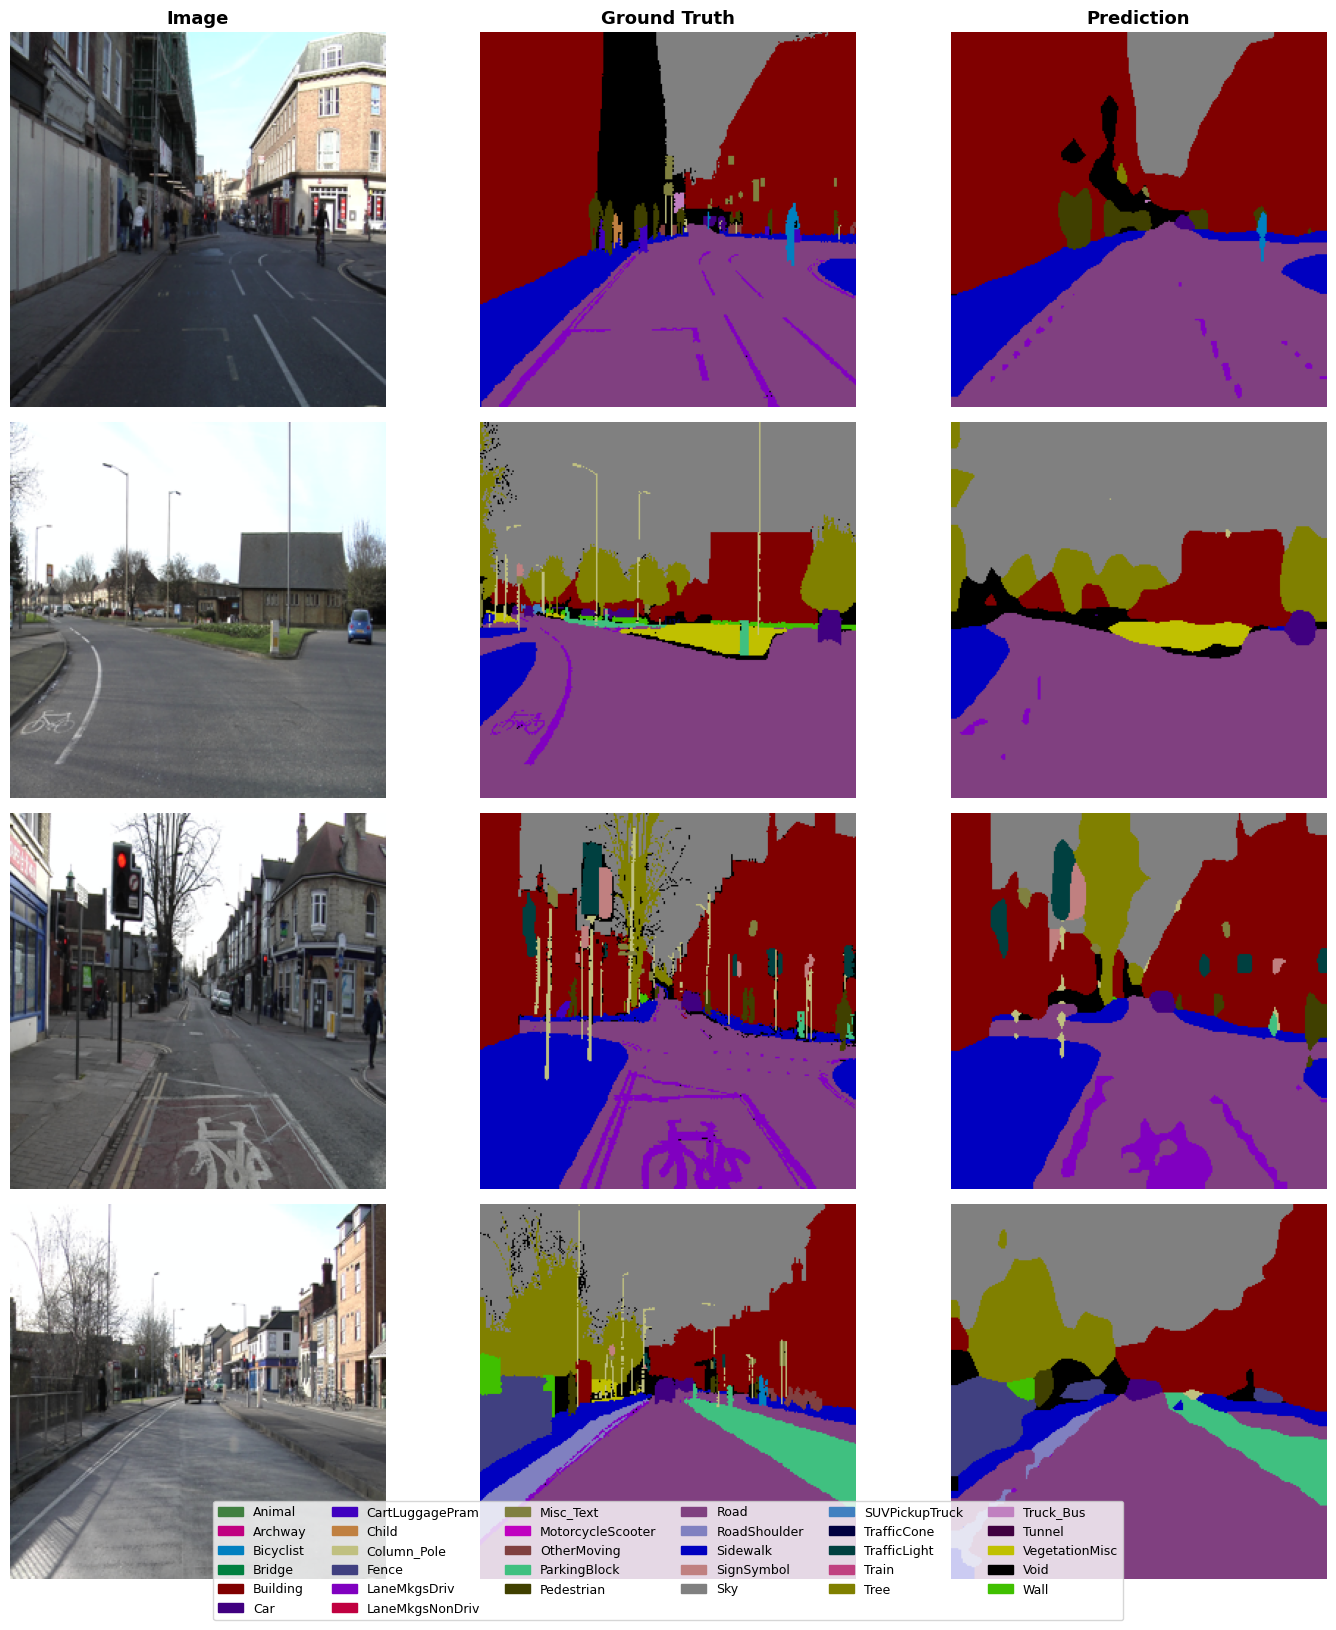

Saved → prediction_grid.png


In [39]:
plot_prediction_grid(images_list, ground_truths, predictions, num_samples=4, save_path="prediction_grid.png")

In [40]:
CLASS_NAMES  = [n for n, _ in CAMVID_CLASSES]
IGNORE_INDEX = 11
PALETTE      = np.array([c for _, c in CAMVID_CLASSES], dtype=np.uint8)

In [41]:
def plot_per_class_iou(gt_list, pred_list, save_path="per_class_iou.png"):
    """
    Computes and plots IoU per class as a horizontal bar chart.
 
    Args:
        gt_list   : list of np.ndarray (H, W) — ground truth label maps
        pred_list : list of np.ndarray (H, W) — predicted label maps
        save_path : file to save the figure
    """
    intersection = np.zeros(num_classes)
    union        = np.zeros(num_classes)
 
    for gt, pred in zip(gt_list, pred_list):
        for cls in range(num_classes):
            if cls == IGNORE_INDEX:
                continue
            pred_c = (pred == cls)
            gt_c   = (gt   == cls)
            intersection[cls] += (pred_c & gt_c).sum()
            union[cls]        += (pred_c | gt_c).sum()
 
    iou        = np.where(union > 0, intersection / (union + 1e-6), np.nan)
    miou       = np.nanmean(iou)
 
    # drop Unlabelled from plot
    valid_idx   = [i for i in range(num_classes) if i != IGNORE_INDEX and not np.isnan(iou[i])]
    valid_names = [CLASS_NAMES[i] for i in valid_idx]
    valid_iou   = [iou[i] for i in valid_idx]
    colors      = [np.array(PALETTE[i]) / 255 for i in valid_idx]
 
    # sort by IoU
    sorted_pairs = sorted(zip(valid_iou, valid_names, colors), key=lambda x: x[0])
    valid_iou, valid_names, colors = zip(*sorted_pairs)
 
    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(valid_names, valid_iou, color=colors, edgecolor="gray", linewidth=0.5)
    ax.axvline(miou, color="red", linestyle="--", linewidth=1.5, label=f"mIoU = {miou:.4f}")
    ax.set_xlabel("IoU Score")
    ax.set_title("Per-Class IoU", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.legend()
 
    # value labels on bars
    for bar, val in zip(bars, valid_iou):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
 
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"mIoU: {miou:.4f}  |  Saved → {save_path}")
 
    return iou, miou


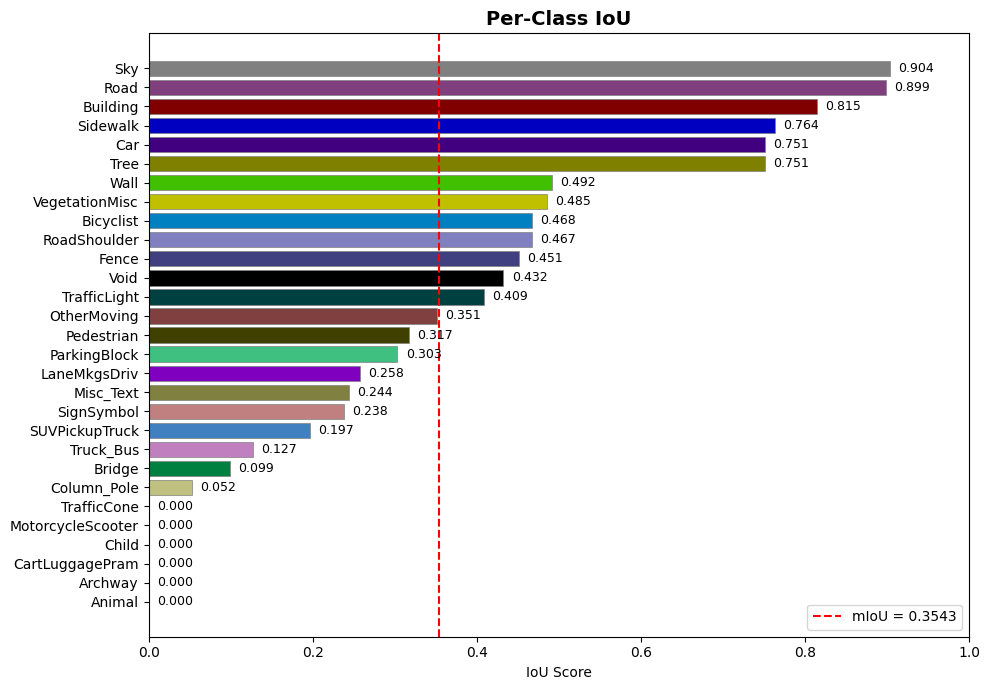

mIoU: 0.3543  |  Saved → per_class_iou.png


In [42]:
iou, mou = plot_per_class_iou(ground_truths, predictions, save_path="per_class_iou.png")

In [43]:
def plot_confusion_matrix(gt_list, pred_list, save_path="confusion_matrix.png"):
    """
    Plots a normalized confusion matrix across all test samples,
    excluding the Unlabelled class.
 
    Args:
        gt_list   : list of np.ndarray (H, W)
        pred_list : list of np.ndarray (H, W)
        save_path : file to save the figure
    """
    valid_idx   = [i for i in range(num_classes) if i != IGNORE_INDEX]
    valid_names = [CLASS_NAMES[i] for i in valid_idx]
 
    all_gt   = []
    all_pred = []
 
    for gt, pred in zip(gt_list, pred_list):
        # flatten and filter out Unlabelled pixels
        gt_flat   = gt.flatten()
        pred_flat = pred.flatten()
        mask      = gt_flat != IGNORE_INDEX
        all_gt.append(gt_flat[mask])
        all_pred.append(pred_flat[mask])
 
    all_gt   = np.concatenate(all_gt)
    all_pred = np.concatenate(all_pred)
 
    # only keep valid class indices
    valid_mask = np.isin(all_gt, valid_idx)
    all_gt     = all_gt[valid_mask]
    all_pred   = all_pred[valid_mask]
 
    cm = confusion_matrix(all_gt, all_pred, labels=valid_idx)
    # normalize row-wise → recall per class
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)
 
    fig, ax = plt.subplots(figsize=(13, 11))
    sns.heatmap(
        cm_norm,
        annot=True, fmt=".2f",
        xticklabels=valid_names,
        yticklabels=valid_names,
        cmap="Blues",
        linewidths=0.4,
        ax=ax,
    )
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True",      fontsize=12)
    ax.set_title("Normalized Confusion Matrix", fontsize=14, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
 
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")
 


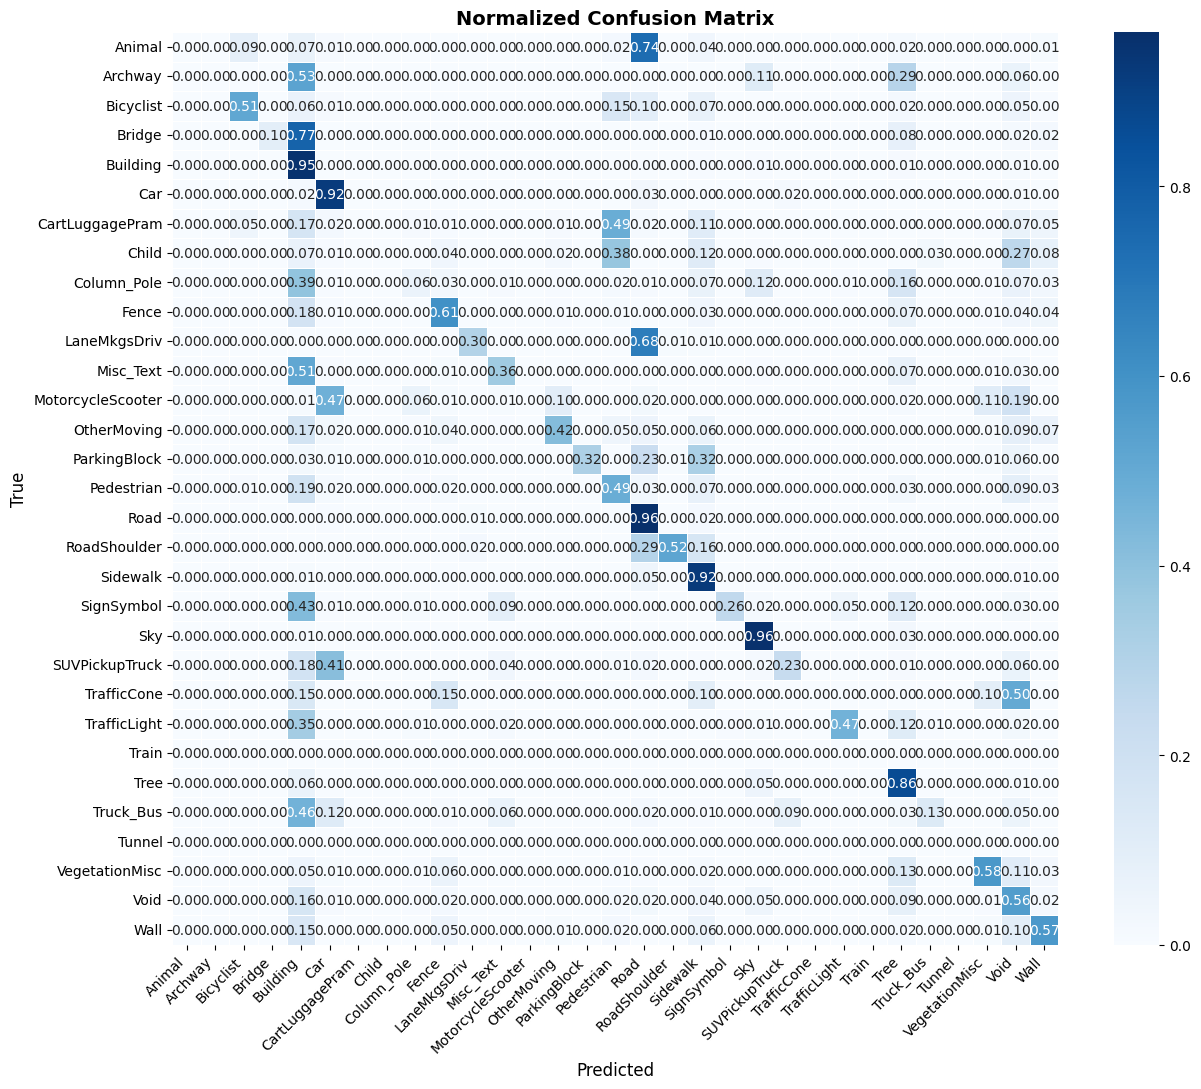

Saved → confusion_matrix.png


In [44]:
plot_confusion_matrix(ground_truths, predictions, save_path="confusion_matrix.png")

In [45]:
def plot_class_distribution(gt_list, save_path="class_distribution.png"):
    """
    Plots total pixel count per class across the entire test set.
 
    Args:
        gt_list   : list of np.ndarray (H, W) — ground truth label maps
        save_path : file to save the figure
    """
    pixel_counts = np.zeros(num_classes, dtype=np.int64)
 
    for gt in gt_list:
        for cls in range(num_classes):
            pixel_counts[cls] += (gt == cls).sum()
 
    # drop Unlabelled
    valid_idx    = [i for i in range(num_classes) if i != IGNORE_INDEX]
    valid_names  = [CLASS_NAMES[i]          for i in valid_idx]
    valid_counts = [pixel_counts[i]         for i in valid_idx]
    colors       = [np.array(PALETTE[i]) / 255 for i in valid_idx]
 
    # sort by count
    sorted_pairs  = sorted(zip(valid_counts, valid_names, colors), key=lambda x: x[0])
    valid_counts, valid_names, colors = zip(*sorted_pairs)
 
    total = sum(valid_counts)
 
    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(valid_names, valid_counts, color=colors, edgecolor="gray", linewidth=0.5)
    ax.set_xlabel("Pixel Count")
    ax.set_title("Class Distribution in Test Set", fontsize=14, fontweight="bold")
 
    # percentage labels
    for bar, count in zip(bars, valid_counts):
        pct = count / total * 100
        ax.text(bar.get_width() + total * 0.005,
                bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%", va="center", fontsize=9)
 
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")
 


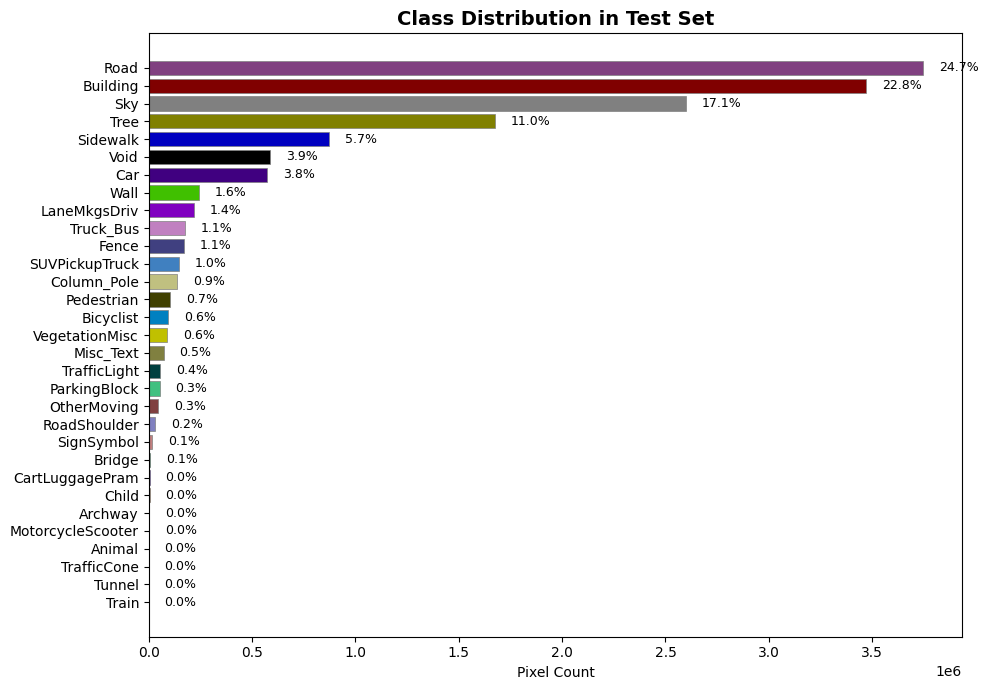

Saved → class_distribution.png


In [46]:
plot_class_distribution(ground_truths, save_path="class_distribution.png")

In [47]:
def compute_accuracy(gt_list, pred_list, save_path="accuracy.png"):
    """
    Computes and plots Pixel Accuracy and Mean Class Accuracy.
 
    Pixel Accuracy     = correctly classified pixels / total pixels
    Mean Class Accuracy= average of per-class recall scores
 
    Args:
        gt_list   : list of np.ndarray (H, W) — ground truth label maps
        pred_list : list of np.ndarray (H, W) — predicted label maps
        save_path : file to save the bar chart
    """
    correct_per_class = np.zeros(num_classes, dtype=np.int64)
    total_per_class   = np.zeros(num_classes, dtype=np.int64)
    total_correct     = 0
    total_pixels      = 0
 
    for gt, pred in zip(gt_list, pred_list):
        # ignore Unlabelled pixels
        valid_mask     = (gt != IGNORE_INDEX)
        gt_valid       = gt[valid_mask]
        pred_valid     = pred[valid_mask]
 
        # overall pixel accuracy
        total_correct += (gt_valid == pred_valid).sum()
        total_pixels  += valid_mask.sum()
 
        # per-class correct and total
        for cls in range(num_classes):
            if cls == IGNORE_INDEX:
                continue
            gt_cls              = (gt_valid == cls)
            correct_per_class[cls] += (pred_valid[gt_cls] == cls).sum()
            total_per_class[cls]   += gt_cls.sum()
 
    # ── compute metrics ───────────────────────────────
    pixel_accuracy     = total_correct / (total_pixels + 1e-6)
 
    per_class_accuracy = np.where(
        total_per_class > 0,
        correct_per_class / (total_per_class + 1e-6),
        np.nan
    )
    mean_class_accuracy = np.nanmean(
        [per_class_accuracy[i] for i in range(num_classes) if i != IGNORE_INDEX]
    )
 
    # ── print summary ─────────────────────────────────
    print(f"\n{'─'*40}")
    print(f"  Pixel Accuracy      : {pixel_accuracy:.4f}  ({pixel_accuracy*100:.2f}%)")
    print(f"  Mean Class Accuracy : {mean_class_accuracy:.4f}  ({mean_class_accuracy*100:.2f}%)")
    print(f"\n  Per-Class Accuracy:")
    for i in range(num_classes):
        if i == IGNORE_INDEX or np.isnan(per_class_accuracy[i]):
            continue
        print(f"    {CLASS_NAMES[i]:<15} {per_class_accuracy[i]:.4f}  ({per_class_accuracy[i]*100:.2f}%)")
    print(f"{'─'*40}")
 
    # ── plot ──────────────────────────────────────────
    valid_idx    = [i for i in range(num_classes)
                    if i != IGNORE_INDEX and not np.isnan(per_class_accuracy[i])]
    valid_names  = [CLASS_NAMES[i]              for i in valid_idx]
    valid_acc    = [per_class_accuracy[i]       for i in valid_idx]
    colors       = [np.array(PALETTE[i]) / 255  for i in valid_idx]
 
    # sort by accuracy
    sorted_pairs = sorted(zip(valid_acc, valid_names, colors), key=lambda x: x[0])
    valid_acc, valid_names, colors = zip(*sorted_pairs)
 
    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(valid_names, valid_acc, color=colors, edgecolor="gray", linewidth=0.5)
 
    ax.axvline(pixel_accuracy,      color="red",  linestyle="--", linewidth=1.5,
               label=f"Pixel Accuracy = {pixel_accuracy:.4f}")
    ax.axvline(mean_class_accuracy, color="blue", linestyle="--", linewidth=1.5,
               label=f"Mean Class Accuracy = {mean_class_accuracy:.4f}")
 
    ax.set_xlabel("Accuracy")
    ax.set_title("Per-Class Accuracy", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=9)
 
    # value labels
    for bar, val in zip(bars, valid_acc):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val*100:.1f}%", va="center", fontsize=9)
 
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")
 
    return pixel_accuracy, mean_class_accuracy, per_class_accuracy



────────────────────────────────────────
  Pixel Accuracy      : 0.8646  (86.46%)
  Mean Class Accuracy : 0.4157  (41.57%)

  Per-Class Accuracy:
    Animal          0.0000  (0.00%)
    Archway         0.0000  (0.00%)
    Bicyclist       0.5148  (51.48%)
    Bridge          0.0992  (9.92%)
    Building        0.9516  (95.16%)
    Car             0.9187  (91.87%)
    CartLuggagePram 0.0000  (0.00%)
    Child           0.0000  (0.00%)
    Column_Pole     0.0576  (5.76%)
    Fence           0.6052  (60.52%)
    LaneMkgsDriv    0.2976  (29.76%)
    Misc_Text       0.3552  (35.52%)
    MotorcycleScooter 0.0000  (0.00%)
    OtherMoving     0.4231  (42.31%)
    ParkingBlock    0.3190  (31.90%)
    Pedestrian      0.4869  (48.69%)
    Road            0.9626  (96.26%)
    RoadShoulder    0.5221  (52.21%)
    Sidewalk        0.9244  (92.44%)
    SignSymbol      0.2581  (25.81%)
    Sky             0.9585  (95.85%)
    SUVPickupTruck  0.2349  (23.49%)
    TrafficCone     0.0000  (0.00%)
    Traf

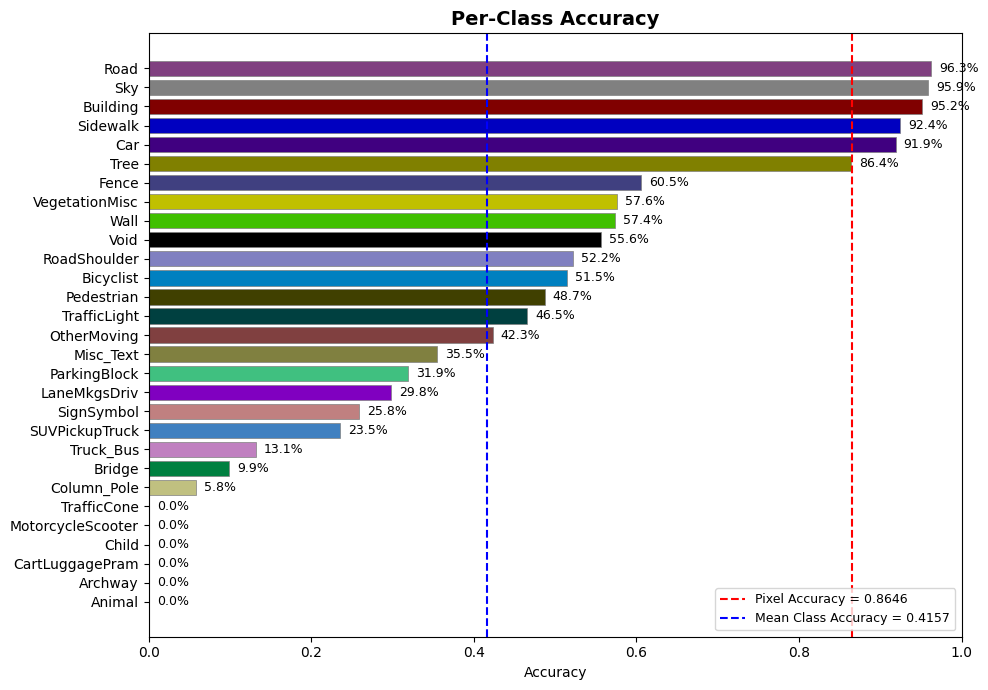

Saved → accuracy.png


In [48]:
pixel_acc, mean_class_acc, per_class_acc = compute_accuracy(ground_truths, predictions)